In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def MEPFM(input_rpd, table, param_names=None):
    """
    Main Effects Plot for Means (Python version of MATLAB MEPFM)
    
    Parameters:
    -----------
    input_rpd : array-like, shape (27,)
        Mean RPD values for each run (27x1).
    table : array-like, shape (27,7)
        L27 orthogonal array with parameter levels (values 1,2,3).
    param_names : list of str
        Names of parameters (length = number of columns in table).
    
    Returns:
    --------
    best_levels : list
        Best level (min RPD) for each parameter.
    """
    
    input_rpd = np.array(input_rpd).flatten()
    table = np.array(table)
    n_params = table.shape[1]
    
    if param_names is None:
        param_names = [f"Parameter {i+1}" for i in range(n_params)]
    
    best_levels = []
    ncols = 4
    nrows = int(np.ceil(n_params / ncols))
    
    sns.set(style="whitegrid", font_scale=1.1)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
    axes = axes.flatten()
    
    for i in range(n_params):
        levels = np.unique(table[:, i])
        means = []
        for lvl in levels:
            idx = np.where(table[:, i] == lvl)[0]
            means.append(np.mean(input_rpd[idx]))
        
        means = np.array(means)
        best_lvl = levels[np.argmin(means)]
        best_levels.append(best_lvl)
        
        # Plot
        ax = axes[i]
        ax.plot(levels, means, marker="o", linestyle="-", color="b")
        ax.set_title(f"{param_names[i]}", fontsize=12, weight="bold")
        ax.set_xlabel("Levels")
        ax.set_ylabel("Mean RPD")
        ax.grid(True, linestyle="--", alpha=0.6)
        
        # Set x-axis tick labels as A(1), A(2), A(3), B(1), etc.
        if (65+i) >= 67:
            param_code = chr(65 + i+1)  # 65 = 'A', 66='B', etc.
        else:
            param_code = chr(65 + i)  # 65 = 'A', 66='B', etc.
            
        x_labels = [f"{param_code} ({lvl})" for lvl in levels]
        x_labels
        ax.set_xticks(levels)
        ax.set_xticklabels(x_labels)
        
        # Highlight best level
        ax.scatter(best_lvl, np.min(means), color="red", s=80, zorder=3, label="Best")
        ax.legend(loc="best", fontsize=8)
    
    # Remove empty subplots
    for j in range(n_params, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle("Tuning results for GEA_2", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig("GEA_2_Tuning_Results.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    return best_levels


# ------------------------
# Example usage
# ------------------------
# Define the L27 table (27x7) as in MATLAB
# table = np.array([
#  [1,1,1,1,1,1,1],
#  [1,1,1,2,2,2,2],
#  [1,1,1,3,3,3,3],
#  [1,2,2,1,1,2,2],
#  [1,2,2,2,2,3,3],
#  [1,2,2,3,3,1,1],
#  [1,3,3,1,1,3,3],
#  [1,3,3,2,2,1,1],
#  [1,3,3,3,3,2,2],
#  [2,1,2,1,2,1,2],
#  [2,1,2,2,3,2,3],
#  [2,1,2,3,1,3,1],
#  [2,2,3,1,2,2,3],
#  [2,2,3,2,3,3,1],
#  [2,2,3,3,1,1,2],
#  [2,3,1,1,2,3,1],
#  [2,3,1,2,3,1,2],
#  [2,3,1,3,1,2,3],
#  [3,1,3,1,3,1,3],
#  [3,1,3,2,1,2,1],
#  [3,1,3,3,2,3,2],
#  [3,2,1,1,3,2,1],
#  [3,2,1,2,1,3,2],
#  [3,2,1,3,2,1,3],
#  [3,3,2,1,3,3,2],
#  [3,3,2,2,1,1,3],
#  [3,3,2,3,2,2,1]
# ])

# Dummy mean RPD values (replace with your real results)

# GEA_1
# mean_rpd = np.array([
#     0.00272850115379923,
#     0.0150604051415386,
#     0.0127972888120574,
#     0.0144801113597916,
#     0.0138000425317487,
#     0.0316957906401054,
#     0.0117229572368976,
#     0.0176670892684029,
#     0.0319027045804703,
#     0.00542144126899788,
#     0.0217059199037485,
#     0.0228235825808690,
#     0.00284341011122836,
#     0.0291177594823358,
#     0.0252858427873550,
#     0.00773409347330848,
#     0.0220281737984698,
#     0.0170794564202229,
#     0.0208540671770142,
#     0.0148023652545128,
#     0.0181836000393817,
#     0.0218563898997783,
#     0.0172299264162526,
#     0.0115446962656275,
#     0.0248360228710975,
#     0.00562878620628992,
#     0.0250789288469902
# ])

# GEA
# mean_rpd = np.array([
#     0.0258027845552611,
#     0.00510407437502375,
#     0.0287975266563733,
#     0.0253234248947144,
#     0.0175750842854671,
#     0.0377052957542103,
#     0.0174957363666385,
#     0.0183120280547724,
#     0.0327774612816980,
#     0.00216334128318535,
#     0.0213836660090274,
#     0.0260477115999124,
#     0.0120383030621130,
#     0.0180462181043864,
#     0.0337437919689345,
#     0.0126054840014856,
#     0.0213836660090274,
#     0.0125105959559368,
#     0.00398195569408332,
#     0.0228885246665417,
#     0.0277436469900212,
#     0.0169665685315523,
#     0.00784857143381047,
#     0.0127977198089845,
#     0.0187131988713949,
#     0.0187847519455232,
#     0.0241121671628266
# ])


# # Parameter names (replace with real ones)
# param_names = [
#     "PCrossover", "PMutation", "NCrossover_Scenario",
#     "PScenario1", "Crossover_gamma", "Mutation_gamma", "PFixedX"
# ]

# # Run
# best_levels = MEPFM(mean_rpd, table, param_names)
# print("Best parameter levels:", best_levels)

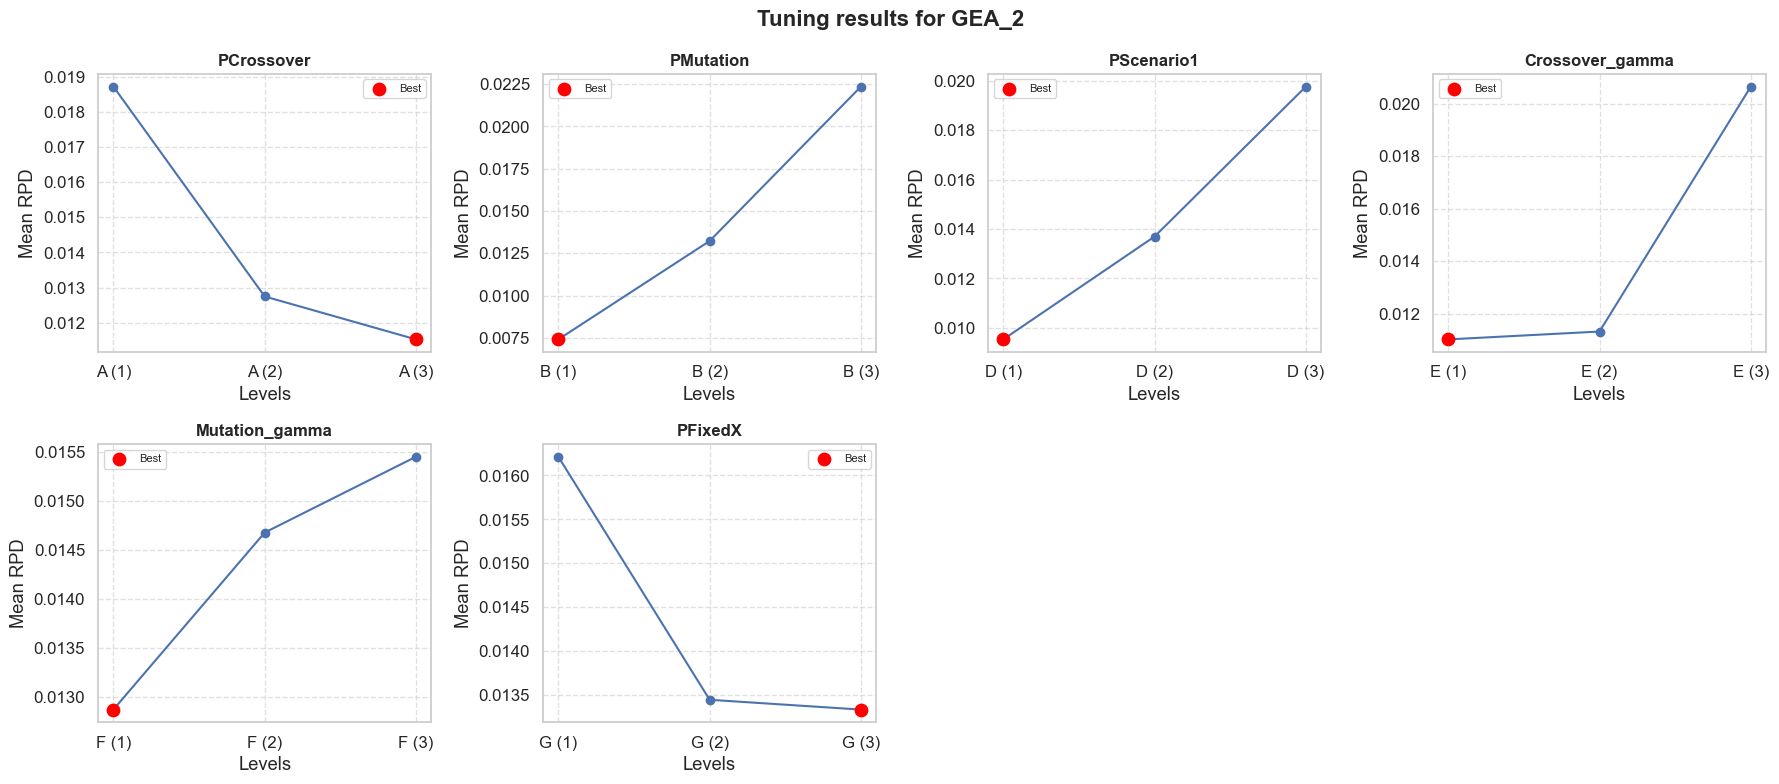

Best parameter levels: [3, 1, 1, 1, 1, 3]


In [15]:
# ------------------------
# Example usage
# ------------------------
# Define the L27 table (27x6) as in MATLAB
table = np.array([
 [1,1,1,1,1,1],
 [1,1,1,2,2,2],
 [1,1,1,3,3,3],
 [1,2,2,1,1,2],
 [1,2,2,2,2,3],
 [1,2,2,3,3,1],
 [1,3,3,1,1,3],
 [1,3,3,2,2,1],
 [1,3,3,3,3,2],
 [2,1,2,1,2,1],
 [2,1,2,2,3,2],
 [2,1,2,3,1,3],
 [2,2,3,1,2,2],
 [2,2,3,2,3,3],
 [2,2,3,3,1,1],
 [2,3,1,1,2,3],
 [2,3,1,2,3,1],
 [2,3,1,3,1,2],
 [3,1,3,1,3,1],
 [3,1,3,2,1,2],
 [3,1,3,3,2,3],
 [3,2,1,1,3,2],
 [3,2,1,2,1,3],
 [3,2,1,3,2,1],
 [3,3,2,1,3,3],
 [3,3,2,2,1,1],
 [3,3,2,3,2,2]
])

# GEA_2
mean_rpd = np.array([
    0.00693398523551396,
    0.00482008877629871,
    0.00473197344757888,
    0.0114263505436403,
    0.00999043626102183,
    0.0287879315723244,
    0.0209126062755136,
    0.0301640570218479,
    0.0507066962996797,
    0.00939935490814924,
    0,
    0.0113982504515516,
    0.00752506658838664,
    0.0170115487237961,
    0.0221773194581419,
    0.0181795283713371,
    0.0130046041362368,
    0.0160356242938063,
    0.00854514207411270,
    0.00358729073821317,
    0.0172194681222424,
    0.00331958250667173,
    0.00760570953904261,
    0.0111949078034827,
    0.0129539688038963,
    0.0157189618526154,
    0.0235897103990490
])


# GEA_3
# mean_rpd = np.array([
#     0.0119079326692219,
#     0.00846250454788284,
#     0.0168331461823491,
#     0.0137347890422582,
#     0.00149592951924967,
#     0.0307987946744615,
#     0.0101044329277732,
#     0.0214805768025239,
#     0.0453659404091866,
#     0.0107285049955067,
#     0.00228857527274454,
#     0.0142434313850645,
#     0.0117925029442948,
#     0.0127402893616888,
#     0.0236537223503414,
#     0.00781507584856175,
#     0.00738314427810011,
#     0.0135960026857435,
#     0.0116996480444884,
#     0.00767628949204694,
#     0.0258042930730382,
#     0.0107285049955067,
#     0.00194228609796334,
#     0.0246022905742025,
#     0.0140351467603311,
#     0.0132027900678642,
#     0.0265445766721657
# ])

# Parameter names (replace with real ones)
param_names = [
    "PCrossover", "PMutation", "PScenario1",
    "Crossover_gamma", "Mutation_gamma", "PFixedX"
]

# Run
best_levels = MEPFM(mean_rpd, table, param_names)
print("Best parameter levels:", best_levels)